# Proyecto Final: Análisis de Libros (Goodreads) y Chatbot

**Estudiante:** Noelia Alvarado Moreno  

**Dataset usado:**  
- *Goodreads Books* (Kaggle) — archivo `books.csv` (descargado desde Kaggle y cargado en Google Colab).

**Objetivos:**  
Analizar datos de Goodreads para encontrar libros mejor calificados y más votados, y resumir características generales del conjunto de datos.  
Construir un chatbot por reglas que responda consultas usando resultados reales del análisis (por ejemplo, idioma más frecuente, libro más votado, explicación de gráficos) e integrar un modelo **RandomForest** (con `get_dummies`) que prediga si un libro tiene “buen rating” (**average_rating ≥ 4.0**) y compare la predicción con el valor real del dataset.

In [24]:
#Extraer contenido del zip goodreadsbooks.zip
!mkdir -p /content/data
!unzip -o -q /content/goodreadsbooks.zip -d /content/data
!ls -lah /content/data

total 1.5M
drwxr-xr-x 2 root root 4.0K Mar  2 19:43 .
drwxr-xr-x 1 root root 4.0K Mar  2 17:38 ..
-rw-r--r-- 1 root root 1.5M Mar  9  2020 books.csv


In [25]:
#import necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Cargamos el dataset y exploramos los datos**

In [26]:
df = pd.read_csv("/content/data/books.csv", engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()
for c in ["average_rating","ratings_count","text_reviews_count","num_pages"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [27]:
df.shape

(11119, 12)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11119 non-null  int64  
 1   title               11119 non-null  object 
 2   authors             11119 non-null  object 
 3   average_rating      11119 non-null  float64
 4   isbn                11119 non-null  object 
 5   isbn13              11119 non-null  int64  
 6   language_code       11119 non-null  object 
 7   num_pages           11119 non-null  int64  
 8   ratings_count       11119 non-null  int64  
 9   text_reviews_count  11119 non-null  int64  
 10  publication_date    11119 non-null  object 
 11  publisher           11119 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [29]:
df.columns

Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', 'num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

**Análisis Básico: Consultamos al dataset y guardamos los datos obtenidos en variables**

In [30]:
top_idioma = df["language_code"].value_counts().idxmax()
cant_top_idioma = int(df["language_code"].value_counts().max())

print("1) Idioma más frecuente:", top_idioma, "| Cantidad:", cant_top_idioma)

1) Idioma más frecuente: eng | Cantidad: 8906


In [31]:
promedio_rating = float(df["average_rating"].mean())
print("2) Rating promedio:", round(promedio_rating, 3))

2) Rating promedio: 3.934


In [32]:
top_autor = df["authors"].value_counts().idxmax()
cant_top_autor = int(df["authors"].value_counts().max())

print("3) Autor con más libros:", top_autor, "| Cantidad:", cant_top_autor)

3) Autor con más libros: Stephen King | Cantidad: 40


In [33]:
min_libros = 3

stats_autor = (
    df.dropna(subset=["authors","average_rating"])
      .groupby("authors")["average_rating"]
      .agg(["mean","count"])
)

stats_filtrado = stats_autor[stats_autor["count"] >= min_libros]

autor_mejor = stats_filtrado["mean"].idxmax()
autor_mejor_rating = float(stats_filtrado["mean"].max())
autor_mejor_cant = int(stats_filtrado.loc[autor_mejor, "count"])

print(f"4) Autor con mejor promedio (mín {min_libros} libros):", autor_mejor)
print("   Promedio:", round(autor_mejor_rating, 3), "| Libros:", autor_mejor_cant)

4) Autor con mejor promedio (mín 3 libros): Bill Watterson
   Promedio: 4.709 | Libros: 7


In [34]:
df_pop = df.dropna(subset=["title","authors","ratings_count","average_rating"])
fila_pop = df_pop.loc[df_pop["ratings_count"].idxmax()]

libro_pop_titulo = fila_pop["title"]
libro_pop_autor = fila_pop["authors"]
libro_pop_ratings = int(fila_pop["ratings_count"])
libro_pop_rating = float(fila_pop["average_rating"])

print("5) Libro más popular o más votado:", libro_pop_titulo, "|", libro_pop_autor)
print("   ratings_count:", libro_pop_ratings, "| average_rating:", round(libro_pop_rating, 2))

5) Libro más popular o más votado: Twilight (Twilight  #1) | Stephenie Meyer
   ratings_count: 4597666 | average_rating: 3.59


**Gráficos**

In [35]:
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")

# Top 10 mejores puntuados con minimo 5000 ratings
min_ratings = 5000
top_mejores = (
    df.dropna(subset=["title", "authors", "average_rating", "ratings_count"])
      .query("ratings_count >= @min_ratings")
      .sort_values(["average_rating", "ratings_count"], ascending=False)
      .head(10)
)

# Visualizar tabla con datos (luego se grafican).
top_mejores[["title","authors","average_rating","ratings_count"]]

,title,authors,average_rating,ratings_count
6585,The Complete Calvin and Hobbes,Bill Watterson,4.82,32213
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428
6587,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,23875
6,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,28242
6588,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,15365
6589,The Days Are Just Packed,Bill Watterson,4.69,20308
6292,The Absolute Sandman Volume One,Neil Gaiman/Mike Dringenberg/Chris Bachalo/Mic...,4.65,15640
6586,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,4.63,49122
2527,Fullmetal Alchemist Vol. 10,Hiromu Arakawa/Akira Watanabe,4.60,8989
6977,Fullmetal Alchemist Vol. 12 (Fullmetal Alchem...,Hiromu Arakawa/Akira Watanabe,4.60,7480


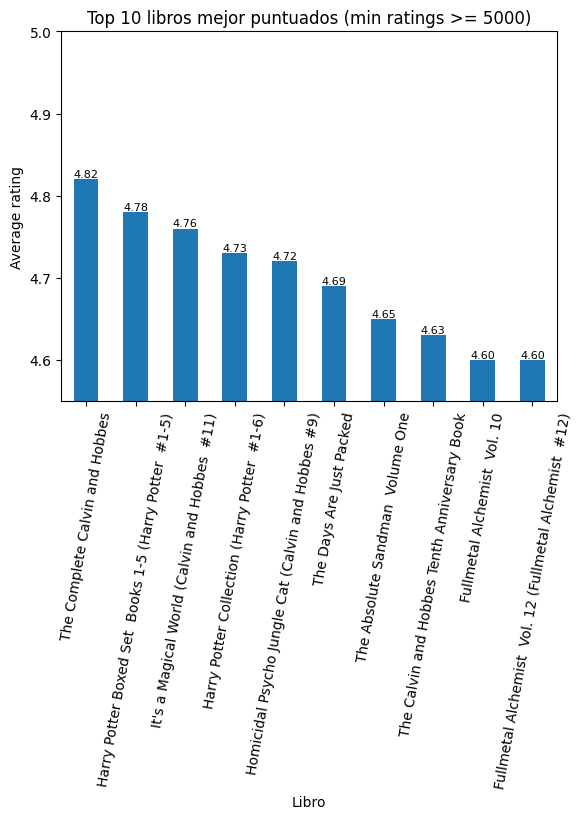

In [36]:
ax = top_mejores.set_index("title")["average_rating"].plot(kind="bar")
plt.title(f"Top 10 libros mejor puntuados (min ratings >= {min_ratings})")
plt.xlabel("Libro")
plt.ylabel("Average rating")
plt.xticks(rotation=80)
plt.ylim(top_mejores["average_rating"].min() - 0.05, 5.0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
plt.show()

titulo_mejor_puntuado_graf = top_mejores.iloc[0]["title"]

### Interpretación
Este gráfico muestra los 10 libros con mayor **average_rating** dentro del dataset, considerando solo aquellos con al menos **5000 calificaciones** para evitar resultados poco representativos.  

In [37]:
top_votados = (
    df.dropna(subset=["title","authors","average_rating","ratings_count"])
      .sort_values("ratings_count", ascending=False)
      .head(10)
)

top_votados[["title","authors","average_rating","ratings_count"]]

,title,authors,average_rating,ratings_count
10333,Twilight (Twilight #1),Stephenie Meyer,3.59,4597666
1696,The Hobbit or There and Back Again,J.R.R. Tolkien,4.27,2530894
1462,The Catcher in the Rye,J.D. Salinger,3.80,2457092
307,Angels & Demons (Robert Langdon #1),Dan Brown,3.89,2418736
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585
4414,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,4.42,2293963
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167
23,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,4.36,2128944
2113,Animal Farm,George Orwell/Boris Grabnar/Peter Škerl,3.93,2111750
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690


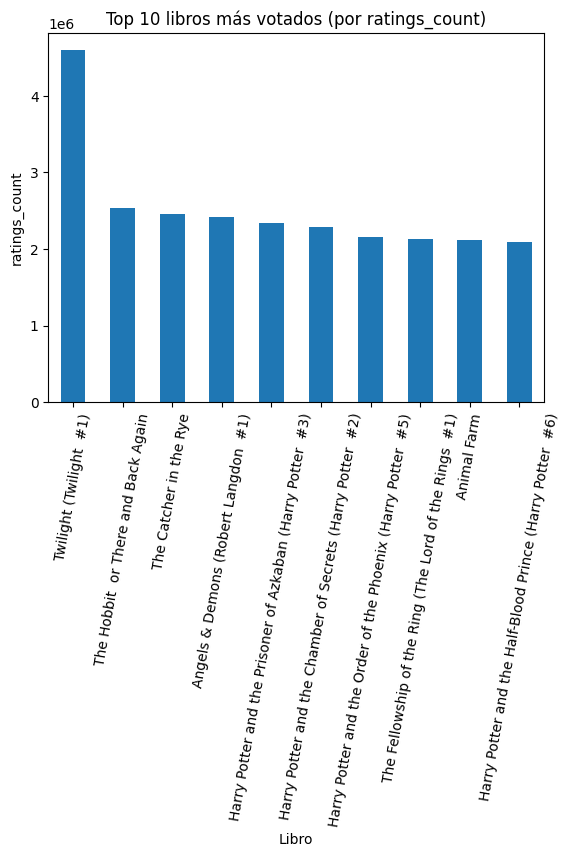

In [38]:
top_votados.set_index("title")["ratings_count"].plot(kind="bar")
plt.title("Top 10 libros más votados (por ratings_count)")
plt.xlabel("Libro")
plt.ylabel("ratings_count")
plt.xticks(rotation=80)
plt.show()
titulo_mas_votado_graf = top_votados.iloc[0]["title"]

### Interpretación
Este gráfico muestra los 10 libros con mayor **ratings_count**, es decir, los más votados y por tanto más populares dentro del dataset.  
La popularidad no necesariamente implica tener la mejor calificación promedio, ya que algunos libros muy votados pueden tener un **average_rating** moderado.  
En conclusión, **ratings_count** refleja el alcance del libro y **average_rating** refleja la valoración promedio.

### Predicciones con RandomForest
Se entrenó un modelo RandomForest para clasificar si un libro tiene “buen rating” (≥ 4.0), utilizando como variables: idioma, número de páginas, cantidad de calificaciones (ratings) y cantidad de reseñas (reviews).  
El modelo se configuró con 100 árboles de decisión(`n_estimators = 100`).

In [39]:
#Eliminamos campos en blanco
df_modelo = df.dropna(subset=[
    "average_rating","ratings_count","text_reviews_count","num_pages","language_code","title","authors"
]).copy()

#Se comsidera high rating si es mayor a 4.0
df_modelo["high_rating"] = (df_modelo["average_rating"] >= 4.0).astype(int)

#Features para predecir resultados
features = ["language_code","num_pages","ratings_count","text_reviews_count"]
X = df_modelo[features]
y = df_modelo["high_rating"]

# Convertimos language_code a variable dummy para que el modelo RandomForest pueda trabajar con ella
X = pd.get_dummies(X, columns=["language_code"], drop_first=True)

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

#Creamos el randomforest
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)

#Realiza predicciones con los datos de prueba
pred = model.predict(X_test)

# Calcula el accuracy: porcentaje de predicciones correctas
accuracy_modelo = accuracy_score(y_test, pred)

#Num de aciertos
aciertos = (pred == y_test).sum()

print("Aciertos:", aciertos, "de", len(y_test))
print("Accuracy:", accuracy_modelo)

Aciertos: 1324 de 2224
Accuracy: 0.5953237410071942


In [40]:
def predecir_por_titulo(query):
    q = query.lower().strip()

    #Busca en el dataset los libros cuyo título contenga ese texto
    matches = df_modelo[df_modelo["title"].str.lower().str.contains(q, na=False)].copy()

    #Si no encontró coincidencias, termina la función
    if matches.empty:
        return None

    #Elige el libro con más votos (ratings_count más alto)
    elegido = matches.loc[matches["ratings_count"].idxmax()]

    # Construye un DataFrame de 1 fila con las variables que usa el modelo
    fila = pd.DataFrame([{
        "language_code": elegido["language_code"],
        "num_pages": elegido["num_pages"],
        "ratings_count": elegido["ratings_count"],
        "text_reviews_count": elegido["text_reviews_count"]
    }])

    # Convierte language_code en variables dummy para que el modelo lo entienda
    fila = pd.get_dummies(fila, columns=["language_code"], drop_first=True)

    #Alinea las columnas de esta fila con las columnas usadas al entrenar
    # Si faltan columnas, las crea y las llena con 0
    fila = fila.reindex(columns=X.columns, fill_value=0)

    #Calcula la probabilidad y la prediccion
    prob = model.predict_proba(fila)[0][1]
    pred = int(prob >= 0.5)

    #Obtiene el rating real del dataset para comparar con la predicción
    real_rating = float(elegido["average_rating"])
    real_label = 1 if real_rating >= 4.0 else 0

    #Retornar libro elegido, predicción, probabilidad, rating real y etiqueta real
    return elegido, pred, prob, real_rating, real_label

**Chatbot integrando Kaggle y randomforest**



In [41]:
nombreBot = "GoodbookBot"
print(f"Hola, soy {nombreBot}")
print("Puedo responder preguntas sobre el análisis del dataset de libros (Goodreads).")
print("Comandos sugeridos: idioma mas frecuente | promedio rating | libro mas votado | explica grafico votados | explica grafico puntuados | accuracy modelo | predecir <texto> | salir\n")

while True:
    pregunta = input("Tú: ").lower().strip()

    if pregunta == "salir":
        print(f"{nombreBot}: ¡Gracias por explorar sobre libros conmigo!")
        break

    #integración análisis y chatbot
    elif "idioma mas frecuente" in pregunta or "idioma más frecuente" in pregunta:
        print(f"{nombreBot}: El idioma más frecuente es {top_idioma} con {cant_top_idioma} libros.")

    elif "promedio rating" in pregunta or "rating promedio" in pregunta or "promedio del rating" in pregunta:
        print(f"{nombreBot}: El rating promedio del dataset es {promedio_rating:.3f}.")

    elif "libro mas votado" in pregunta or "libro más votado" in pregunta or "mas popular" in pregunta:
        print(f"{nombreBot}: El libro más votado es '{libro_pop_titulo}' — {libro_pop_autor}.")
        print(f"{nombreBot}: ratings_count={libro_pop_ratings} | average_rating={libro_pop_rating:.2f}")

    # Explicamos gráficos
    elif "explica grafico" in pregunta or "explica gráfico" in pregunta:
        if "votados" in pregunta or "popular" in pregunta:
            print(f"{nombreBot}: Este gráfico muestra los 10 libros con mayor cantidad de votos (ratings_count).")
            print(f"{nombreBot}: El libro con más votos dentro del Top 10 es:")
            print(f"{nombreBot}: {titulo_mas_votado_graf}")

        elif "puntuados" in pregunta or "mejor" in pregunta:
            print(f"{nombreBot}: Este gráfico muestra los 10 libros con mayor average_rating (mejores puntuados).")
            print(f"{nombreBot}: El libro con mejor puntuación dentro del Top 10 es:")
            print(f"{nombreBot}: {titulo_mejor_puntuado_graf}")

        else:
            print(f"{nombreBot}: ¿Cuál gráfico querés que explique?")
            print(f"{nombreBot}: Escribe: 'explica grafico votados' o 'explica grafico puntuados'")
     # Integración con RandomForest
    elif "accuracy" in pregunta or "modelo" in pregunta:
        total_pruebas = len(y_test)
        print(f"{nombreBot}: El accuracy se calcula en el conjunto de prueba (X_test) después de entrenar el modelo.")
        print(f"{nombreBot}: Aciertos: {aciertos} de {total_pruebas} libros de prueba.")
        print(f"{nombreBot}: Accuracy = {accuracy_modelo:.3f} (~{accuracy_modelo*100:.1f}%).")

    elif pregunta.startswith("predecir"):
      texto = pregunta.replace("predecir", "", 1).replace(":", "").strip()
      if texto == "":
          print(f"{nombreBot}: Usa: predecir <parte del título>. Ej: predecir harry potter")
      else:
          res = predecir_por_titulo(texto)
          if res is None:
              print(f"{nombreBot}: No encontré títulos que coincidan con ese texto.")
          else:
              elegido, pred_rf, prob, real_rating, real_label = res

              etiqueta_pred = "BUEN rating (>=4.0)" if pred_rf == 1 else "NO tan buen rating (<4.0)"
              etiqueta_real = "BUEN rating (>=4.0)" if real_label == 1 else "NO tan buen rating (<4.0)"
              veredicto = "ACERTÓ" if pred_rf == real_label else "FALLÓ"

              print(f"{nombreBot}: Libro encontrado: '{elegido['title']}' — {elegido['authors']}")
              print(f"{nombreBot}: Rating REAL del dataset: {real_rating:.2f} → {etiqueta_real}")
              print(f"{nombreBot}: Predicción RandomForest: {etiqueta_pred} | Probabilidad={prob:.3f}")
              print(f"{nombreBot}: Resultado: {veredicto}")
    else:
        print(f"{nombreBot}: No estoy seguro de esa pregunta. Intenta preguntar sobre promedios, idiomas, libro más votado, 'explica grafico votados/puntuados' o 'predecir <texto>'.")

Hola, soy GoodbookBot
Puedo responder preguntas sobre el análisis del dataset de libros (Goodreads).
Comandos sugeridos: idioma mas frecuente | promedio rating | libro mas votado | explica grafico votados | explica grafico puntuados | accuracy modelo | predecir <texto> | salir

Tú: predecir coraline
GoodbookBot: Libro encontrado: 'Coraline' — Neil Gaiman/Dave McKean
GoodbookBot: Rating REAL del dataset: 4.06 → BUEN rating (>=4.0)
GoodbookBot: Predicción RandomForest: BUEN rating (>=4.0) | Probabilidad=0.520
GoodbookBot: Resultado: ✅ ACERTÓ
Tú: predecir the diary
GoodbookBot: Libro encontrado: 'Anne Frank Beyond the Diary: A Photographic Remembrance' — Ruud van der Rol/Rian Verhoeven/Anna Quindlen/Anne Frank/Tony   Langham/Plym Peters
GoodbookBot: Rating REAL del dataset: 4.27 → BUEN rating (>=4.0)
GoodbookBot: Predicción RandomForest: NO tan buen rating (<4.0) | Probabilidad=0.470
GoodbookBot: Resultado: ❌ FALLÓ
Tú: predecir the hobbit
GoodbookBot: Libro encontrado: 'The Hobbit  or The